In [ ]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score


In [ ]:
#  Step 1: Upload and unzip the dataset
from google.colab import files
uploaded = files.upload()  # Allows you to upload files from your device to Colab

import zipfile
import os

# Unzip the uploaded dataset.zip file to /content/dataset
with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/")

# Show the extracted folders/files to confirm
print("Unzipped files:")
print(os.listdir("/content/dataset/"))


Saving dataset.zip to dataset.zip
Unzipped files: ['dataset']


In [ ]:
#  Step 2: Load all images from the dataset folders recursively

import os
import cv2
import numpy as np

# Define a function to load all images and assign labels based on the file name
def load_images_recursive(base_path):
    """
    Recursively loads all images from base_path.
    Labels images as 'day' if 'day' is in the filename, else 'night'.
    """
    supported_ext = ['.jpg', '.jpeg', '.png']  # Allowed image formats
    images = []
    labels = []

    print(f" Scanning all folders under: {base_path}")

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if any(file.lower().endswith(ext) for ext in supported_ext):
                file_path = os.path.join(root, file)
                img = cv2.imread(file_path)
                if img is not None:
                    images.append(img)
                    label = 1 if 'day' in file.lower() else 0  # Simple rule: 1 for day, 0 for night
                    labels.append(label)
                    print(f" Loaded: {file_path} | Label: {label}")
                else:
                    print(f" Failed to load image: {file_path}")
            else:
                print(f" Skipped non-image file: {file}")

    print(f" Total images loaded: {len(images)}")
    return images, np.array(labels)

# Call the function to load images and labels
base_path = "/content/dataset"
images, labels = load_images_recursive(base_path)


🔍 Scanning all folders under: /content/dataset
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_03.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_09.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_19.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_23.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_08.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_05.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_12.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_10.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_04.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_11.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_07.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_14.jpg
✅ Loaded: /content/dataset/dataset/Burj Khalifa/p/Burj_Khalifa_06.jpg
✅ Loaded: /content/dataset/dataset/Burj Kha

In [ ]:
#  Step 3: Extract brightness features from each image in different color spaces

def extract_brightness_features(images, color_space='RGB'):
    """
    Convert images to the specified color space and compute mean and std brightness.
    Returns a feature array of shape (num_images, 2)
    """
    features = []
    print(f"\n🔧 Extracting brightness features using {color_space} color space...")

    for idx, img in enumerate(images[:5]):  # Show examples only for first 5 images
        if color_space == 'HSV':
            converted = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            brightness = converted[:, :, 2]  # V channel = brightness
        elif color_space == 'LAB':
            converted = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            brightness = converted[:, :, 0]  # L channel = lightness
        else:  # RGB by default
            brightness = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Approximate brightness

        mean_val = np.mean(brightness)
        std_val = np.std(brightness)
        features.append([mean_val, std_val])
        print(f"  Image {idx+1}: mean={mean_val:.2f}, std={std_val:.2f}")

    for img in images[5:]:  # Process rest without printing
        if color_space == 'HSV':
            converted = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            brightness = converted[:, :, 2]
        elif color_space == 'LAB':
            converted = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            brightness = converted[:, :, 0]
        else:
            brightness = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features.append([np.mean(brightness), np.std(brightness)])

    print(f" Done. Extracted features shape: {np.array(features).shape}")
    return np.array(features)

# Extract features for all three color spaces
rgb_features = extract_brightness_features(images, color_space='RGB')
hsv_features = extract_brightness_features(images, color_space='HSV')
lab_features = extract_brightness_features(images, color_space='LAB')



🔧 Extracting brightness features using RGB color space...
  ▶️ Image 1: mean=141.23, std=43.95
  ▶️ Image 2: mean=156.78, std=51.08
  ▶️ Image 3: mean=162.08, std=21.93
  ▶️ Image 4: mean=161.54, std=34.57
  ▶️ Image 5: mean=156.24, std=63.43
✅ Done. Extracted features shape: (299, 2)

🔧 Extracting brightness features using HSV color space...
  ▶️ Image 1: mean=162.18, std=50.66
  ▶️ Image 2: mean=174.26, std=52.04
  ▶️ Image 3: mean=178.40, std=22.34
  ▶️ Image 4: mean=189.43, std=49.48
  ▶️ Image 5: mean=179.55, std=68.52
✅ Done. Extracted features shape: (299, 2)

🔧 Extracting brightness features using LAB color space...
  ▶️ Image 1: mean=148.81, std=43.71
  ▶️ Image 2: mean=164.80, std=49.35
  ▶️ Image 3: mean=171.92, std=20.36
  ▶️ Image 4: mean=169.16, std=33.96
  ▶️ Image 5: mean=160.46, std=63.21
✅ Done. Extracted features shape: (299, 2)


In [ ]:
#  Step 4: Generate binary labels using brightness threshold (unsupervised)

def generate_labels_from_brightness(features):
    """
    Generates labels based on whether the mean brightness is above or below threshold.
    """
    threshold = np.mean(features[:, 0])
    print(f"\n Brightness threshold: {threshold:.2f}")

    labels = (features[:, 0] >= threshold).astype(int)
    unique, counts = np.unique(labels, return_counts=True)
    print(f" Generated Labels: {dict(zip(unique, counts))} (1=day, 0=night)")

    return labels

# Create brightness-based labels for each color space
labels_rgb = generate_labels_from_brightness(rgb_features)
labels_hsv = generate_labels_from_brightness(hsv_features)
labels_lab = generate_labels_from_brightness(lab_features)



📏 Brightness threshold: 130.77
🧾 Generated Labels: {np.int64(0): np.int64(125), np.int64(1): np.int64(174)} (1=day, 0=night)

📏 Brightness threshold: 162.72
🧾 Generated Labels: {np.int64(0): np.int64(120), np.int64(1): np.int64(179)} (1=day, 0=night)

📏 Brightness threshold: 139.30
🧾 Generated Labels: {np.int64(0): np.int64(125), np.int64(1): np.int64(174)} (1=day, 0=night)


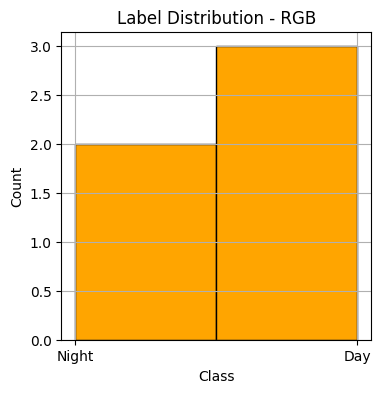

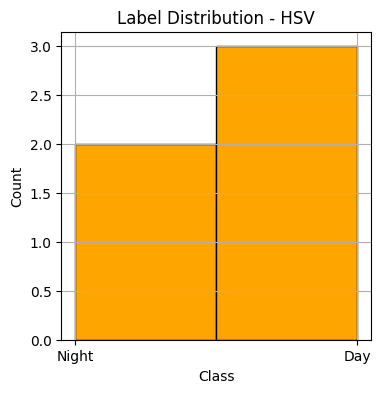

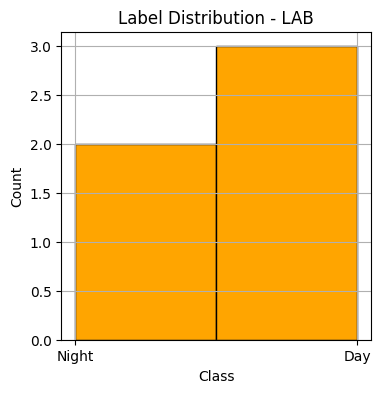

In [ ]:
def plot_label_distribution(labels, color_space):
    plt.figure(figsize=(4, 4))
    plt.hist(labels, bins=2, color='orange', edgecolor='black')
    plt.xticks([0, 1], ["Night", "Day"])
    plt.title(f"Label Distribution - {color_space}")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

plot_label_distribution(labels_rgb, "RGB")
plot_label_distribution(labels_hsv, "HSV")
plot_label_distribution(labels_lab, "LAB")


In [ ]:
#  Step 5: Evaluate classification using thresholding method

from sklearn.metrics import confusion_matrix, accuracy_score

def evaluate_threshold_classifier(features, labels):
    """
    Evaluates accuracy and confusion matrix using simple threshold classifier.
    """
    threshold = np.mean(features[:, 0])
    predictions = (features[:, 0] >= threshold).astype(int)
    acc = accuracy_score(labels, predictions)
    cm = confusion_matrix(labels, predictions)

    print(f"\n Threshold-based Accuracy: {acc:.2f}")
    print(" Confusion Matrix:")
    print(cm)
    return acc, cm

# Evaluate threshold method for each color space
print(" RGB Threshold Classifier:")
evaluate_threshold_classifier(rgb_features, labels_rgb)

print("\n HSV Threshold Classifier:")
evaluate_threshold_classifier(hsv_features, labels_hsv)

print("\ LAB Threshold Classifier:")
evaluate_threshold_classifier(lab_features, labels_lab)


 RGB Threshold Classifier:

 Threshold-based Accuracy: 1.00
 Confusion Matrix:
[[125   0]
 [  0 174]]

 HSV Threshold Classifier:

 Threshold-based Accuracy: 1.00
 Confusion Matrix:
[[120   0]
 [  0 179]]
\ LAB Threshold Classifier:

 Threshold-based Accuracy: 1.00
 Confusion Matrix:
[[125   0]
 [  0 174]]


(1.0,
 array([[125,   0],
        [  0, 174]]))

In [ ]:
#  Step 6: Train SVM classifier for each color space

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

def train_and_evaluate_svm(features, labels, color_space):
    """
    Trains a linear SVM classifier and evaluates it on test data.
    """
    print(f"\n==============================")
    print(f" Training SVM for {color_space} color space")

    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42)

    print(f" Training size: {len(X_train)}, Testing size: {len(X_test)}")

    model = SVC(kernel='linear')
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    print(f" Accuracy: {acc:.2f}")
    print(" Confusion Matrix:")
    print(cm)

    return acc, cm

train_and_evaluate_svm(rgb_features, labels_rgb, 'RGB')
train_and_evaluate_svm(hsv_features, labels_hsv, 'HSV')
train_and_evaluate_svm(lab_features, labels_lab, 'LAB')


 Training SVM for RGB color space
 Training size: 239, Testing size: 60
 Accuracy: 1.00
 Confusion Matrix:
[[27  0]
 [ 0 33]]

 Training SVM for HSV color space
 Training size: 239, Testing size: 60
 Accuracy: 0.98
 Confusion Matrix:
[[25  0]
 [ 1 34]]

 Training SVM for LAB color space
 Training size: 239, Testing size: 60
 Accuracy: 1.00
 Confusion Matrix:
[[26  0]
 [ 0 34]]


(1.0,
 array([[26,  0],
        [ 0, 34]]))